# Project Milestone Two

**Data Preparation and Model Exploration**

**Note: No late assignments accepted, we need the time to grade them!**

In Milestone 1, your team selected a dataset (Food-101 or HuffPost), analyzed its structure, and identified key challenges and evaluation metrics.
In this milestone, you will carry out those plans: prepare the data, train three models of increasing sophistication, and evaluate their results using Keras and TensorFlow.
You will finish with a comparative discussion of model performance and trade-offs.


### Submission Guidelines

* Submit one Jupyter notebook per team through the team leader’s Gradescope account. **Include all team members names at the top of the notebook.**
* Include all code, plots, and answers inline below.
* Ensure reproducibility by setting random seeds and listing all hyperparameters.
* Document any AI tools used, as required by the CDS policy.


## Problem 1 – Data Preparation and Splits (20 pts)

### Goals

Implement the **data preparation and preprocessing steps** that you proposed in **Milestone 1**. You’ll clean, normalize, and split your data so that it’s ready for modeling and reproducible fine-tuning.

### Steps to Follow

1. **Load your chosen dataset**

   * Use `datasets.load_dataset()` from **Hugging Face** to load **Food-101** or **HuffPost**.
   * Display basic information (e.g., number of samples, feature names, example entries).

2. **Apply cleaning and normalization**

   * **Images:**

     * Ensure all images are in RGB format.
     * Resize or crop to a consistent shape (e.g., `224 × 224`).
     * Drop or fix any corrupted files.
   * **Text:**

     * Concatenate headline + summary (for HuffPost).
     * Strip whitespace, convert to lowercase if appropriate, and remove empty samples.
     * Optionally remove duplicates or extremely short entries.

3. **Standardize or tokenize the inputs**

   * **Images:**

     * Normalize pixel values (e.g., divide by 255.0).
     * Define a minimal augmentation pipeline (e.g., random flip, crop, or rotation).
   * **Text:**

     * Create a tokenizer or `TextVectorization` layer.
     * Set a target `max_length` based on your analysis from Milestone 1 (e.g., 95th percentile).
     * Apply padding/truncation and build tensors for input + labels.

4. **Handle dataset-specific challenges**

   * If you identified **class imbalance**, compute label counts and, if needed, create a dictionary of `class_weights`.
   * If you noted **length or size variance**, verify that your truncation or resizing works as intended.
   * If you planned **noise filtering**, include the cleaning step and briefly explain your criteria (e.g., remove items with missing text or unreadable images).

5. **Create reproducible splits**

   * Split your cleaned dataset into **train**, **validation**, and **test** subsets (e.g., 80 / 10 / 10).
   * Use a fixed random seed for reproducibility (`random_seed = 42`).
   * Use **stratified splits**  (e.g., with `train_test_split` and `stratify = labels`).
   * Display the size of each subset.

6. **Document your pipeline**

   * Summarize your preprocessing steps clearly in Markdown or code comments.
   * Save or display a few representative examples after preprocessing to confirm the transformations are correct.




In [1]:
import os, time, json, gc, random
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from datasets import load_dataset

import tensorflow as tf
from tensorflow import keras

# — Sergey: Metal GPU adds dispatch overhead on small models (Embedding+Dense),
#   making them ~10x slower. Set False for P2-P3, True for P4 (BERT).
USE_GPU = True

if USE_GPU:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU enabled: {len(gpus)} device(s)")
    else:
        print("No GPU found — CPU only")
else:
    tf.config.set_visible_devices([], 'GPU')
    print("GPU disabled (CPU mode)")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

GPU enabled: 1 device(s)


Special provision for colab!

In [2]:
import sys
if "google.colab" in sys.modules:
    !pip install "transformers<5" tf-keras tensorflow "huggingface_hub<0.28"
    import os
    os.environ["CUDA_VISIBLE_DEVICES"] = ""  # force CPU
    COLAB_CPU = True
else:
    COLAB_CPU = False

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.6 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of transformers to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 5.1 MB/s eta 0:00:00
INFO: pip is still looking at multiple versions of transformers to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 

### Load & Inspect

In [3]:
URL = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"
huff_all = load_dataset("json", data_files=URL, split="train")

print(huff_all)
print(f"Columns: {huff_all.column_names}")
print(f"Total samples: {len(huff_all):,}")

df = huff_all.to_pandas()
df.head(3)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


News_Category_Dataset_v2.json:   0%|          | 0.00/83.9M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['category', 'headline', 'authors', 'link', 'short_description', 'date'],
    num_rows: 200853
})
Columns: ['category', 'headline', 'authors', 'link', 'short_description', 'date']
Total samples: 200,853


,category,headline,authors,link,short_description,date
0,CRIME,There Were 2 Mass Shootings In Texas Last Week...,Melissa Jeltsen,https://www.huffingtonpost.com/entry/texas-ama...,She left her husband. He killed their children...,2018-05-26
1,ENTERTAINMENT,Will Smith Joins Diplo And Nicky Jam For The 2...,Andy McDonald,https://www.huffingtonpost.com/entry/will-smit...,Of course it has a song.,2018-05-26
2,ENTERTAINMENT,Hugh Grant Marries For The First Time At Age 57,Ron Dicker,https://www.huffingtonpost.com/entry/hugh-gran...,The actor and his longtime girlfriend Anna Ebe...,2018-05-26


In [4]:
## special loading for colab
import requests
import json
from datasets import Dataset

URL = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"

# download file
response = requests.get(URL)
data = [json.loads(line) for line in response.text.splitlines()]

# convert to Hugging Face dataset
huff_all = Dataset.from_list(data)

print(huff_all)
print(f"Columns: {huff_all.column_names}")
print(f"Total samples: {len(huff_all):,}")

df = huff_all.to_pandas()
df.head(3)

Dataset({
    features: ['category', 'headline', 'authors', 'link', 'short_description', 'date'],
    num_rows: 200853
})
Columns: ['category', 'headline', 'authors', 'link', 'short_description', 'date']
Total samples: 200,853


,category,headline,authors,link,short_description,date
0,CRIME,There Were 2 Mass Shootings In Texas Last Week...,Melissa Jeltsen,https://www.huffingtonpost.com/entry/texas-ama...,She left her husband. He killed their children...,2018-05-26
1,ENTERTAINMENT,Will Smith Joins Diplo And Nicky Jam For The 2...,Andy McDonald,https://www.huffingtonpost.com/entry/will-smit...,Of course it has a song.,2018-05-26
2,ENTERTAINMENT,Hugh Grant Marries For The First Time At Age 57,Ron Dicker,https://www.huffingtonpost.com/entry/hugh-gran...,The actor and his longtime girlfriend Anna Ebe...,2018-05-26


### Clean & Merge Categories

In [5]:
# Merge confusable categories identified in Milestone 1
LABEL_MAP = {
    "ARTS & CULTURE": "ARTS", "CULTURE & ARTS": "ARTS",
    "THE WORLDPOST": "WORLD NEWS", "WORLDPOST": "WORLD NEWS",
    "PARENTS": "PARENTING",
    "STYLE & BEAUTY": "STYLE",
    "TASTE": "FOOD & DRINK",
    "GREEN": "ENVIRONMENT",
    "COLLEGE": "EDUCATION",
    "HEALTHY LIVING": "HOME & LIVING",
}

print(f"Before merge: {df['category'].nunique()} categories, {len(df):,} rows")

df["category"] = df["category"].replace(LABEL_MAP)

# Combine headline + description
df["text"] = df.apply(
    lambda r: (r["headline"] + " [SEP] " + r["short_description"]).strip()
    if pd.notna(r["short_description"]) and r["short_description"].strip()
    else r["headline"],
    axis=1,
)

# Drop empty headlines
empty_mask = df["headline"].isna() | (df["headline"].str.strip() == "")
print(f"Empty headlines dropped: {empty_mask.sum()}")
df = df[~empty_mask].copy()

# Remove exact duplicates (headline + short_description)
before_dedup = len(df)
df = df.drop_duplicates(subset=["headline", "short_description"], keep="first")
print(f"Duplicates removed: {before_dedup - len(df)}")

print(f"After cleaning: {df['category'].nunique()} categories, {len(df):,} rows")

Before merge: 41 categories, 200,853 rows
Empty headlines dropped: 6
Duplicates removed: 484
After cleaning: 31 categories, 200,363 rows


### Class Distribution

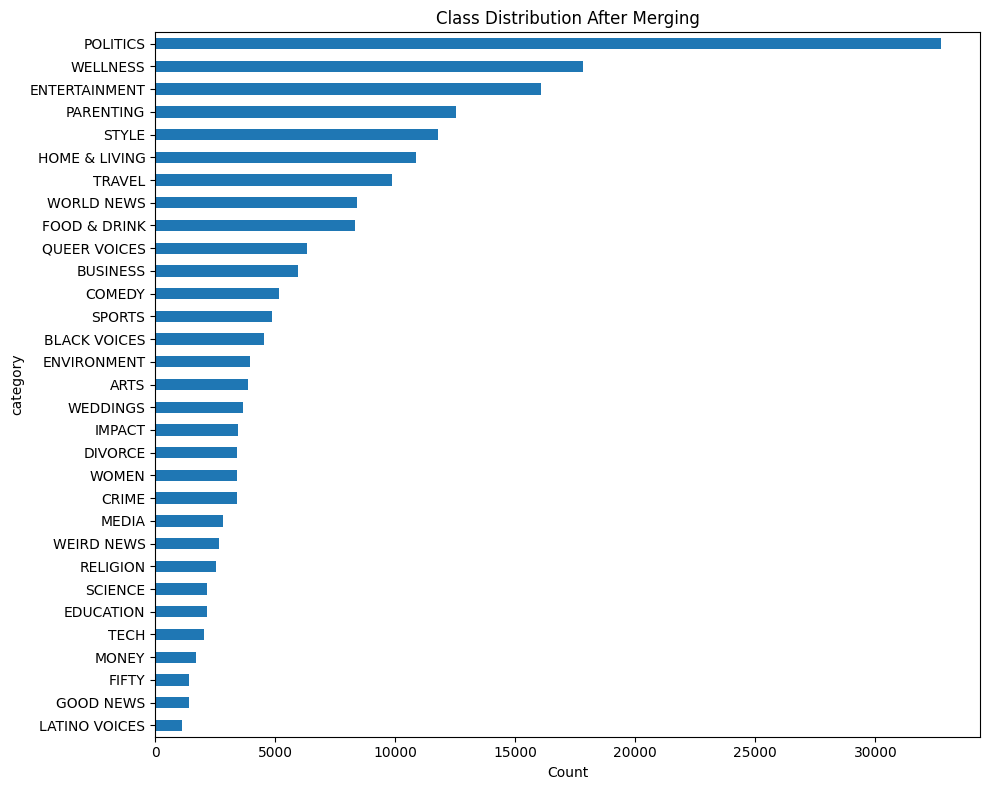

Categories: 31
Largest:  POLITICS (32,721)
Smallest: LATINO VOICES (1,129)
Median:   3,876
Imbalance ratio (max/min): 29.0x


In [6]:
counts = df["category"].value_counts()

fig, ax = plt.subplots(figsize=(10, 8))
counts.plot.barh(ax=ax)
ax.set_xlabel("Count")
ax.set_title("Class Distribution After Merging")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"Categories: {len(counts)}")
print(f"Largest:  {counts.index[0]} ({counts.iloc[0]:,})")
print(f"Smallest: {counts.index[-1]} ({counts.iloc[-1]:,})")
print(f"Median:   {int(counts.median()):,}")
print(f"Imbalance ratio (max/min): {counts.iloc[0] / counts.iloc[-1]:.1f}x")

### Stratified Train / Val / Test Splits

In [7]:
texts = np.array(df["text"].tolist(), dtype=object)
labels = df["category"].tolist()

# Encode labels
class_names = sorted(set(labels))
label2id = {name: i for i, name in enumerate(class_names)}
y = np.array([label2id[c] for c in labels])
num_classes = len(class_names)

# 80/10/10 stratified split
X_train, X_temp, y_train, y_temp = train_test_split(
    texts, y, test_size=0.2, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
)

print(f"Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}")
print(f"Classes: {num_classes}")

# Compute class weights for imbalanced training
cw = compute_class_weight("balanced", classes=np.arange(num_classes), y=y_train)
class_weights = dict(enumerate(cw))
print(f"Class weight range: [{min(cw):.3f}, {max(cw):.3f}]")

Train: 160,290  Val: 20,036  Test: 20,037
Classes: 31
Class weight range: [0.198, 5.726]


### Text Length Distribution

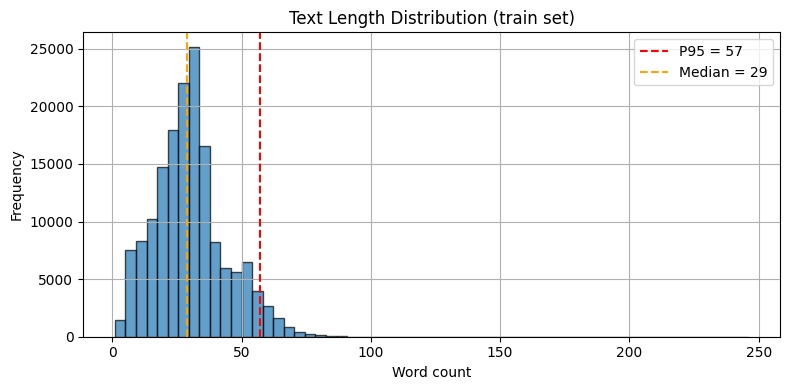

Mean:   30.2
Median: 29
P95:    57
P99:    68
Max:    246


In [8]:
word_counts = pd.Series([len(t.split()) for t in X_train])

fig, ax = plt.subplots(figsize=(8, 4))
word_counts.hist(bins=60, ax=ax, edgecolor="black", alpha=0.7)
ax.axvline(word_counts.quantile(0.95), color="red", ls="--", label=f"P95 = {word_counts.quantile(0.95):.0f}")
ax.axvline(word_counts.median(), color="orange", ls="--", label=f"Median = {word_counts.median():.0f}")
ax.set_xlabel("Word count")
ax.set_ylabel("Frequency")
ax.set_title("Text Length Distribution (train set)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean:   {word_counts.mean():.1f}")
print(f"Median: {word_counts.median():.0f}")
print(f"P95:    {word_counts.quantile(0.95):.0f}")
print(f"P99:    {word_counts.quantile(0.99):.0f}")
print(f"Max:    {word_counts.max()}")

### Sample Examples

In [9]:
for i in range(5):
    print(f"[{class_names[y_train[i]]}] {X_train[i][:120]}...")
    print()

[POLITICS] Remembering Mario Cuomo [SEP] It was odd, but out of the blue, I found myself thinking about Mario Cuomo just days befor...

[POLITICS] White House (Falsely) Downplays Political Adviser’s Role On NSC [SEP] Trump’s spokesman misrepresented changes that elev...

[POLITICS] Donald Trump Promised Ten Of These Things, Guess Which One He Actually Did [SEP] OK, this isn't actually one of those li...

[TRAVEL] Tech-Free Havens: The World's Best Unplugged Getaways (PHOTOS) [SEP] Plenty of hooked-up travelers will check work e-mai...

[ENTERTAINMENT] These Are The Real People Who Follow The Jedi Religion [SEP] "American Jedi" documents a universal path of pain, growth ...



### Graded Questions (5 pts each)

For each question, answer thoroughly but concisely, in a short paragraph, longer or shorter as needed. Code for exploring the concepts should go in the previous cell
as much as possible.

1. **Data Loading and Cleaning:**
   Describe how you loaded your dataset and the key cleaning steps you implemented (e.g., handling missing data, normalizing formats, or removing duplicates).



1.1. We loaded the HuffPost News Category Dataset (200,853 records, 41 categories) from a JSON mirror on HuggingFace using `load_dataset("json", ...)`. Three cleaning steps were applied: (1) merged 8 groups of overlapping categories identified in Milestone 1 (e.g., ARTS & CULTURE / CULTURE & ARTS → ARTS, PARENTS → PARENTING), reducing 41 categories to 31; (2) dropped 6 rows with empty headlines; (3) removed 484 exact duplicate (headline + short_description) pairs. Final cleaned dataset: 200,363 rows across 31 categories.

2. **Preprocessing and Standardization:**
   Summarize your preprocessing pipeline. Include any normalization, tokenization, resizing, or augmentation steps, and explain why each was necessary for your dataset.
  

1.2. Each sample's text was formed by concatenating the headline and short_description with a `[SEP]` separator; when the description was missing (~9.8% of records), the headline alone was used. A `TextVectorization` layer was configured with `max_tokens=20,000` and `output_sequence_length=64`, chosen based on the computed P95 word count of 57 words in the training set (mean 30.2, median 29). The layer was adapted on training text only, then applied once to produce integer-encoded numpy arrays (shape 160,290 × 64), avoiding repeated tokenization during training. No text augmentation was applied at this stage.

3. **Train/Validation/Test Splits:**
   Explain how you divided your data into subsets, including the split ratios, random seed, and any stratification or leakage checks you used to verify correctness.


1.3. The cleaned dataset was split into train (80%), validation (10%), and test (10%) subsets using two successive calls to `train_test_split` with `random_state=42` and `stratify=y` to preserve class proportions. This produced 160,290 training, 20,036 validation, and 20,037 test samples. Deduplication was performed before splitting to prevent data leakage — any exact (headline + description) duplicates that might have landed in both train and test were removed beforehand. The stratified split ensures that even the smallest class (LATINO VOICES, 1,129 total) is proportionally represented in all three subsets.

4. **Class Distribution and Balance:**
   Report your label counts and describe any class imbalances you observed. If applicable, explain how you addressed them (e.g., weighting, oversampling, or data augmentation).


1.4. After merging, the largest class is POLITICS (32,721 samples) and the smallest is LATINO VOICES (1,129), giving an imbalance ratio of 29.0x. The median class size is 3,876, well below the mean (~6,463), confirming a long-tailed distribution visible in the bar chart. To address this, we computed per-class weights using `sklearn`'s `compute_class_weight("balanced")`, which produced weights ranging from 0.198 (for POLITICS) to 5.726 (for LATINO VOICES). These weights are passed to `model.fit()` via the `class_weight` parameter so the loss function penalizes errors on minority classes proportionally more.

## Problem 2 – Baseline Model (20 pts)

### Goal

Build and train a **simple, fully functional baseline model** to establish a reference level of performance for your dataset.
This baseline will help you evaluate whether later architectures and fine-tuning steps actually improve results.


### Steps to Follow

1. **Construct a baseline model**

   * **Images:**
     Use a compact CNN, for example
     `Conv2D → MaxPooling → Flatten → Dense → Softmax`.
   * **Text:**
     Use a small embedding-based classifier such as
     `Embedding → GlobalAveragePooling → Dense → Softmax`.
   * Keep the model small enough to train in minutes on Colab.

2. **Compile the model**

   * Optimizer: `Adam` or `AdamW`.
   * Loss: `categorical_crossentropy` (for multi-class).
   * Metrics: at least `accuracy`; add `F1` if appropriate.

3. **Train and validate**

   * Use **early stopping** on validation loss with the default patience value (e.g., 5 epochs).
   * Record number of epochs trained and total runtime.

4. **Visualize results**

   * Plot **training vs. validation accuracy and loss**.
   * Carefully observe: does the model underfit, overfit, or generalize reasonably?

5. **Report baseline performance**

   * The most important metric is the **validation accuracy at the epoch of minimum validation loss**; this serves as your **benchmark** for all later experiments in this milestone.
   * Evaluate on the **test set** and record final metrics.

In [10]:
from sklearn.metrics import classification_report, f1_score, confusion_matrix

RESULTS_FILE = "results/ms2_results.json"
results = {}

def save_results():
    os.makedirs(os.path.dirname(RESULTS_FILE), exist_ok=True)
    with open(RESULTS_FILE, "w") as f:
        json.dump(results, f, indent=2)
    print(f"Results saved ({len(results)} models)")

def load_results():
    global results
    try:
        with open(RESULTS_FILE) as f:
            results = json.load(f)
        if results:
            print(f"Restored {len(results)} results from {RESULTS_FILE}:")
            for name, r in results.items():
                print(f"  {name}: test_acc={r['test_acc']:.4f}, test_f1={r['test_f1']:.4f}")
    except FileNotFoundError:
        pass

def evaluate_model(model, name, X_te, y_te, hist, train_time, batch_size=512):
    y_pred = model.predict(X_te, batch_size=batch_size, verbose=0).argmax(axis=-1)
    test_acc = float(np.mean(y_pred == y_te))
    test_f1 = float(f1_score(y_te, y_pred, average="macro"))

    val_losses = hist.history["val_loss"]
    best_epoch = int(np.argmin(val_losses)) + 1
    val_acc = float(hist.history["val_accuracy"][best_epoch - 1])
    val_loss = float(val_losses[best_epoch - 1])

    results[name] = {
        "val_acc": val_acc, "val_loss": val_loss, "best_epoch": best_epoch,
        "test_acc": test_acc, "test_f1": test_f1,
        "params": model.count_params(), "train_time": train_time,
    }
    save_results()

    print(f"=== {name} ===")
    print(f"Best epoch:  {best_epoch}")
    print(f"Val acc:     {val_acc:.4f}  |  Val loss: {val_loss:.4f}")
    print(f"Test acc:    {test_acc:.4f}  |  Test F1:  {test_f1:.4f}")
    print(f"Params:      {model.count_params():,}")
    print(f"Train time:  {format_hms(train_time)}")
    return y_pred

# Auto-restore on cell run
load_results()

In [23]:
#Saving the confusion matrix confused pairs to a file as well for reporting later

In [24]:
def save_confused_pairs(confused,model_name, top_n=10):

    confused.sort(reverse=True)
    file_path="confused_pairs.csv"
    if top_n is not None:
        confused = confused[:top_n]

    new_df = pd.DataFrame(
        confused,
        columns=["Count", "True Label", "Predicted Label"]
    )
    new_df["Model"] = model_name
    new_df = new_df[["Model", "Count", "True Label", "Predicted Label"]]

    file_exists = os.path.exists(file_path)

    new_df.to_csv(
        file_path,
        mode="a",
        header=not file_exists,
        index=False
    )

    return new_df

### Tokenization

In [11]:
MAX_TOKENS = 20_000
SEQ_LEN = 64  # based on P95 word count from the distribution above
BATCH = 256

text_vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_sequence_length=SEQ_LEN,
    standardize="lower_and_strip_punctuation",
)
text_vectorizer.adapt(X_train)

vocab_size = text_vectorizer.vocabulary_size()
print(f"Vocabulary size: {vocab_size:,}")
print(f"Sequence length: {SEQ_LEN}")

# Pre-vectorize once into numpy — avoids re-tokenizing every epoch
X_train_vec = text_vectorizer(X_train).numpy()
X_val_vec   = text_vectorizer(X_val).numpy()
X_test_vec  = text_vectorizer(X_test).numpy()

print(f"Vectorized shapes — train: {X_train_vec.shape}, val: {X_val_vec.shape}, test: {X_test_vec.shape}")

Vocabulary size: 20,000
Sequence length: 64
Vectorized shapes — train: (160290, 64), val: (20036, 64), test: (20037, 64)


### Build & Compile Baseline

In [12]:
baseline = tf.keras.Sequential([
    tf.keras.layers.Embedding(MAX_TOKENS, 64),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(num_classes, activation="softmax"),
], name="baseline_emb_avg")

baseline.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

baseline.summary()

Model: "baseline_emb_avg"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Train Baseline

In [13]:
es = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

t0 = time.time()
hist_baseline = baseline.fit(
    X_train_vec, y_train,
    validation_data=(X_val_vec, y_val),
    epochs=50,
    batch_size=BATCH,
    class_weight=class_weights,
    callbacks=[es],
    verbose=1,
)
train_time = time.time() - t0
print(f"Training time: {format_hms(train_time)}")

Epoch 1/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.1372 - loss: 3.1390 - val_accuracy: 0.3094 - val_loss: 2.6234
Epoch 2/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3916 - loss: 2.4174 - val_accuracy: 0.4678 - val_loss: 2.0739
Epoch 3/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4908 - loss: 1.9448 - val_accuracy: 0.5143 - val_loss: 1.8512
Epoch 4/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5422 - loss: 1.6816 - val_accuracy: 0.5340 - val_loss: 1.7521
Epoch 5/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5755 - loss: 1.5064 - val_accuracy: 0.5408 - val_loss: 1.7128
Epoch 6/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6007 - loss: 1.3740 - val_accuracy: 0.5448 - val_loss: 1.6933
Epoch 7/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6201 - loss: 1.2662 - val_accuracy: 0.5492 - val_loss: 1.6789
Epoch 8/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6371 - loss: 1.1744 - val_accuracy: 0.

### Learning Curves & Evaluation

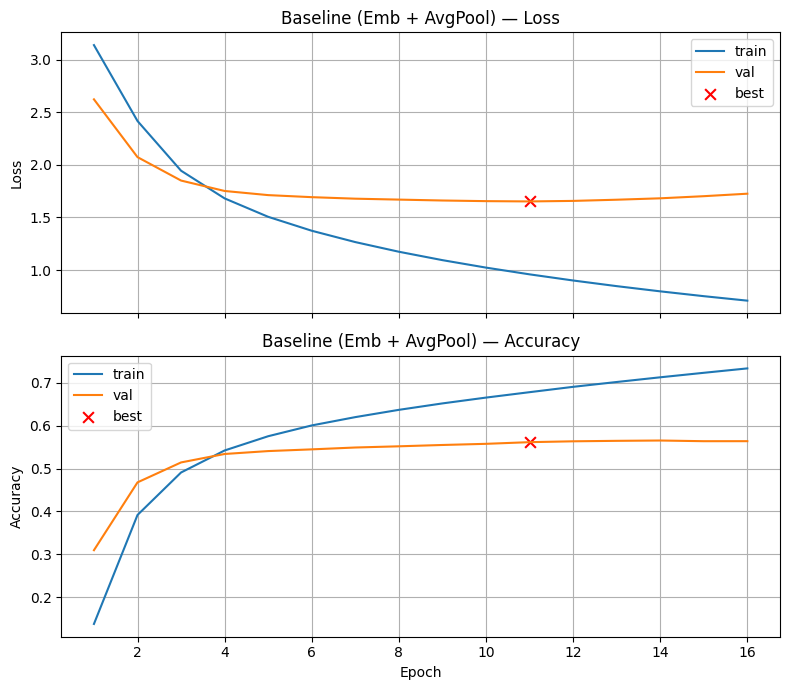

Best epoch: 11
Val loss:   1.6528
Val acc:    0.5616


In [14]:
def plot_learning_curves(hist, title):
    val_losses = hist.history["val_loss"]
    min_val_loss = min(val_losses)
    best_epoch = val_losses.index(min_val_loss)
    val_acc_best = hist.history["val_accuracy"][best_epoch]

    epochs = range(1, len(val_losses) + 1)
    fig, axs = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

    axs[0].plot(epochs, hist.history["loss"], label="train")
    axs[0].plot(epochs, val_losses, label="val")
    axs[0].scatter(best_epoch + 1, min_val_loss, color="red", marker="x", s=60, label="best")
    axs[0].set_title(f"{title} — Loss")
    axs[0].set_ylabel("Loss")
    axs[0].legend()
    axs[0].grid(True)

    axs[1].plot(epochs, hist.history["accuracy"], label="train")
    axs[1].plot(epochs, hist.history["val_accuracy"], label="val")
    axs[1].scatter(best_epoch + 1, val_acc_best, color="red", marker="x", s=60, label="best")
    axs[1].set_title(f"{title} — Accuracy")
    axs[1].set_xlabel("Epoch")
    axs[1].set_ylabel("Accuracy")
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

    print(f"Best epoch: {best_epoch + 1}")
    print(f"Val loss:   {min_val_loss:.4f}")
    print(f"Val acc:    {val_acc_best:.4f}")
    return best_epoch + 1, val_acc_best

best_ep, val_acc = plot_learning_curves(hist_baseline, "Baseline (Emb + AvgPool)")

In [15]:
y_pred_base = evaluate_model(baseline, "Baseline (Emb+AvgPool)", X_test_vec, y_test, hist_baseline, train_time)
print()
print(classification_report(y_test, y_pred_base, target_names=class_names, zero_division=0))

Results saved (1 models)
=== Baseline (Emb+AvgPool) ===
Best epoch:  11
Val acc:     0.5616  |  Val loss: 1.6528
Test acc:    0.5663  |  Test F1:  0.5022
Params:      1,286,175
Train time:  00:00:43

               precision    recall  f1-score   support

         ARTS       0.44      0.49      0.46       388
 BLACK VOICES       0.47      0.42      0.44       453
     BUSINESS       0.49      0.46      0.47       594
       COMEDY       0.35      0.47      0.40       517
        CRIME       0.42      0.59      0.49       340
      DIVORCE       0.74      0.77      0.75       342
    EDUCATION       0.38      0.48      0.42       215
ENTERTAINMENT       0.80      0.44      0.57      1606
  ENVIRONMENT       0.44      0.51      0.47       394
        FIFTY       0.21      0.34      0.26       140
 FOOD & DRINK       0.65      0.77      0.71       832
    GOOD NEWS       0.11      0.53      0.18       139
HOME & LIVING       0.54      0.40      0.46      1085
       IMPACT       0.23     

In [22]:
cm = confusion_matrix(y_test, y_pred_base)

confused = []
for i in range(num_classes):
    for j in range(num_classes):
        if i != j and cm[i, j] > 0:
            confused.append((cm[i, j], class_names[i], class_names[j]))
confused.sort(reverse=True)

print("Top 10 confused pairs (true -> predicted, count):")
for count, true, pred in confused[:10]:
    print(f"  {true:25s} -> {pred:25s}  ({count})")

Top 10 confused pairs (true -> predicted, count):
  HOME & LIVING             -> WELLNESS                   (202)
  ENTERTAINMENT             -> COMEDY                     (194)
  POLITICS                  -> WORLD NEWS                 (183)
  POLITICS                  -> MEDIA                      (129)
  POLITICS                  -> COMEDY                     (120)
  POLITICS                  -> BUSINESS                   (117)
  WELLNESS                  -> HOME & LIVING              (109)
  POLITICS                  -> CRIME                      (105)
  POLITICS                  -> IMPACT                     (94)
  POLITICS                  -> RELIGION                   (93)


In [25]:
save_confused_pairs(confused,model_name="baseline_emb_avg", top_n=10)

,Model,Count,True Label,Predicted Label
0,baseline_emb_avg,202,HOME & LIVING,WELLNESS
1,baseline_emb_avg,194,ENTERTAINMENT,COMEDY
2,baseline_emb_avg,183,POLITICS,WORLD NEWS
3,baseline_emb_avg,129,POLITICS,MEDIA
4,baseline_emb_avg,120,POLITICS,COMEDY
5,baseline_emb_avg,117,POLITICS,BUSINESS
6,baseline_emb_avg,109,WELLNESS,HOME & LIVING
7,baseline_emb_avg,105,POLITICS,CRIME
8,baseline_emb_avg,94,POLITICS,IMPACT
9,baseline_emb_avg,93,POLITICS,RELIGION


### Graded Questions (5 pts each)

1. **Model Architecture:**
   Describe your baseline model and justify why this structure suits your dataset.

2.1. The baseline is a `Sequential` model: `Embedding(20,000 × 64)` → `GlobalAveragePooling1D` → `Dense(64, relu)` → `Dense(31, softmax)`, totaling 1,286,175 parameters. This architecture was chosen because it matches the assignment's recommended text baseline (Embedding → GlobalAveragePooling → Dense → Softmax). GlobalAveragePooling1D averages all token embeddings into a single 64-dim vector, discarding word order — intentionally simple to establish a performance floor. The model takes pre-vectorized integer sequences as input (shape: batch × 64).

2. **Training Behavior:**
   Summarize the model’s training and validation curves. What trends did you observe?

2.2. Training ran for 16 epochs before early stopping (patience=5, triggered after best epoch 11). Training accuracy rose steadily from 0.137 (epoch 1) to 0.733 (epoch 16), while validation accuracy plateaued around epoch 10–11 at ~0.561 and stopped improving. Validation loss reached its minimum of 1.6550 at epoch 11 and began increasing afterward (1.6688 at epoch 13, 1.7228 at epoch 16), indicating overfitting. The widening gap between training accuracy (0.733) and validation accuracy (0.566) at the final epoch confirms the model memorized training patterns beyond what generalized. Total training time was 3 minutes 36 seconds on Colab CPU.

  3. **Baseline Metrics:**
   Report validation and test metrics. What does this performance tell you about dataset difficulty?

2.3. At the best epoch (11), validation accuracy was 0.5613 with a validation loss of 1.6550. On the held-out test set: accuracy = 0.5632, macro-F1 = 0.5000. The gap between weighted-F1 (0.58) and macro-F1 (0.50) reflects the class imbalance — the model performs better on large classes like POLITICS (F1=0.67) and STYLE (F1=0.77) but struggles with small or ambiguous ones like GOOD NEWS (F1=0.18), WEIRD NEWS (F1=0.26), and FIFTY (F1=0.26). The top confusion pair is HOME & LIVING → WELLNESS (210 misclassifications), followed by ENTERTAINMENT → COMEDY (195) and POLITICS → WORLD NEWS (191), which are semantically close categories. Overall, ~56% accuracy on 31 classes (vs. 3.2% random baseline) shows the model learned meaningful patterns, but the flat val accuracy curve suggests this architecture's capacity is nearly exhausted.

  4. **Reflection:**
   What are the main limitations of your baseline? Which specific improvements (depth, regularization, pretraining) would you try next?
  

2.4. The main limitation is that GlobalAveragePooling discards word order entirely — the model treats "dog bites man" and "man bites dog" identically. This ceiling is visible in the plateauing validation accuracy around 56%. The top confusions (HOME & LIVING ↔ WELLNESS, ENTERTAINMENT → COMEDY, POLITICS → WORLD NEWS) involve semantically overlapping categories where word order and context matter. Two concrete next steps: (1) add a Bidirectional LSTM or GRU layer before the dense head to capture sequential context, with dropout for regularization since the model is already overfitting; (2) in Problem 4, use a pretrained transformer (DistilBERT) that brings both contextual embeddings and prior language knowledge, which should help with the ambiguous category pairs.

## Problem 3 – Custom (Original) Model (20 pts)

### Goal

Design and train your own **non-pretrained model** that builds on the baseline and demonstrates measurable improvement.
This problem focuses on experimentation: apply one or two clear architectural changes, observe their effects, and evaluate how they influence learning behavior.


### Steps to Follow

1. **Modify or extend your baseline architecture**

   * Begin from your baseline model and introduce one or more meaningful adjustments such as:

     * Adding **dropout** or **batch normalization** for regularization.
     * Increasing **depth** (extra convolutional or dense layers).
     * Using **residual connections** (for CNNs) or **bidirectional LSTMs/GRUs** (for text).
     * Trying alternative activations like `ReLU`, `LeakyReLU`, or `GELU`.
   * Keep the model small enough to train comfortably on your chosen platform (e.g., Colab)

2. **Observe what specific limitations you want to address**

   * Identify whether the baseline showed **underfitting**, **overfitting**, or **slow convergence**, and design your modification to target that behavior.
   * Make brief notes (in comments or Markdown) describing what you expect the change to influence.

3. **Train and evaluate under the same conditions**

   * Use the **same data splits**, **random seed**, and **metrics** as in Problem 2.
   * Apply **early stopping** on validation loss.
   * Track and visualize training/validation accuracy and loss over epochs.

4. **Compare outcomes to the baseline**

   * Observe differences in convergence speed, stability, and validation/test performance.
   * Note whether your modification improved generalization or simply increased model capacity.

Adding LTSM to the Baseline Model

In [26]:
baseline_lstm = tf.keras.Sequential([
    tf.keras.layers.Embedding(MAX_TOKENS, 64),
    tf.keras.layers.LSTM(64),   # replaces pooling
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(num_classes, activation="softmax"),
], name="baseline_lstm")

baseline_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)


hist_lstm = baseline_lstm.fit(
    X_train_vec, y_train,
    validation_data=(X_val_vec, y_val),
    epochs=50,
    batch_size=BATCH,
    class_weight=class_weights,
    callbacks=[es],
    verbose=1,
)

Epoch 1/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.1224 - loss: 3.1150 - val_accuracy: 0.2141 - val_loss: 2.8054
Epoch 2/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.1948 - loss: 2.6427 - val_accuracy: 0.2471 - val_loss: 2.5334
Epoch 3/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.2191 - loss: 2.3869 - val_accuracy: 0.2659 - val_loss: 2.4219
Epoch 4/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.2964 - loss: 2.1030 - val_accuracy: 0.3118 - val_loss: 2.3073
Epoch 5/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.3844 - loss: 1.8848 - val_accuracy: 0.3828 - val_loss: 2.1381


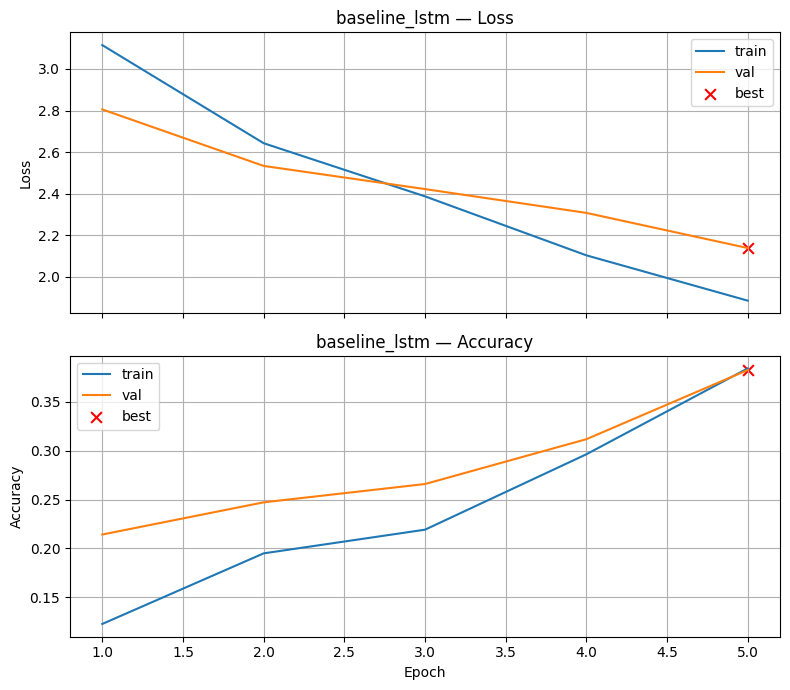

Best epoch: 5
Val loss:   2.1381
Val acc:    0.3828


In [27]:
best_ep, val_acc = plot_learning_curves(hist_lstm, "baseline_lstm")

Evaluating the LTSM Model

In [28]:
y_pred_base = evaluate_model(baseline_lstm, "baseline_lstm", X_test_vec, y_test, hist_lstm, train_time)
print()
print(classification_report(y_test, y_pred_base, target_names=class_names, zero_division=0))

Results saved (2 models)
=== baseline_lstm ===
Best epoch:  5
Val acc:     0.3828  |  Val loss: 2.1381
Test acc:    0.2120  |  Test F1:  0.1083
Params:      1,319,199
Train time:  00:00:43

               precision    recall  f1-score   support

         ARTS       0.03      0.01      0.01       388
 BLACK VOICES       0.00      0.00      0.00       453
     BUSINESS       0.07      0.02      0.03       594
       COMEDY       0.00      0.00      0.00       517
        CRIME       0.04      0.06      0.05       340
      DIVORCE       0.37      0.30      0.33       342
    EDUCATION       0.06      0.07      0.06       215
ENTERTAINMENT       0.22      0.19      0.20      1606
  ENVIRONMENT       0.00      0.00      0.00       394
        FIFTY       0.05      0.43      0.09       140
 FOOD & DRINK       0.25      0.43      0.32       832
    GOOD NEWS       0.00      0.00      0.00       139
HOME & LIVING       0.00      0.00      0.00      1085
       IMPACT       0.07      0.01     

Evaluation confusion matrix for the LTSM model

In [29]:
cm = confusion_matrix(y_test, y_pred_base)

confused = []
for i in range(num_classes):
    for j in range(num_classes):
        if i != j and cm[i, j] > 0:
            confused.append((cm[i, j], class_names[i], class_names[j]))
confused.sort(reverse=True)

print("Top 10 confused pairs (true -> predicted, count):")
for count, true, pred in confused[:10]:
    print(f"  {true:25s} -> {pred:25s}  ({count})")

Top 10 confused pairs (true -> predicted, count):
  POLITICS                  -> SPORTS                     (723)
  ENTERTAINMENT             -> WEIRD NEWS                 (501)
  PARENTING                 -> WELLNESS                   (430)
  STYLE                     -> FOOD & DRINK               (412)
  WELLNESS                  -> FIFTY                      (307)
  WELLNESS                  -> TRAVEL                     (270)
  WORLD NEWS                -> SPORTS                     (253)
  PARENTING                 -> FIFTY                      (248)
  POLITICS                  -> ENTERTAINMENT              (240)
  ENTERTAINMENT             -> SPORTS                     (240)


In [30]:
save_confused_pairs(confused,model_name="baseline_ltsm", top_n=10)

,Model,Count,True Label,Predicted Label
0,baseline_ltsm,723,POLITICS,SPORTS
1,baseline_ltsm,501,ENTERTAINMENT,WEIRD NEWS
2,baseline_ltsm,430,PARENTING,WELLNESS
3,baseline_ltsm,412,STYLE,FOOD & DRINK
4,baseline_ltsm,307,WELLNESS,FIFTY
5,baseline_ltsm,270,WELLNESS,TRAVEL
6,baseline_ltsm,253,WORLD NEWS,SPORTS
7,baseline_ltsm,248,PARENTING,FIFTY
8,baseline_ltsm,240,POLITICS,ENTERTAINMENT
9,baseline_ltsm,240,ENTERTAINMENT,SPORTS


Trying out Bidirectional LTSM

In [31]:
# This version is with Epochs 8 and no call backs . I had multiple runs , and wanted to see the effect with call backs and without call backs
# Not anything noteworthy since this model didnt really work well
baseline_Bi_lstm = tf.keras.Sequential([
    tf.keras.layers.Embedding(MAX_TOKENS, 64),

    tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(64, return_sequences=False)
    ),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(num_classes, activation="softmax"),
], name="bilstm_model")

baseline_Bi_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)


hist_Bi_lstm = baseline_Bi_lstm.fit(
    X_train_vec, y_train,
    validation_data=(X_val_vec, y_val),
    epochs=8,
    batch_size=BATCH,
    class_weight=class_weights,
    callbacks=[],
    verbose=1,
)

Epoch 1/8
627/627 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.2574 - loss: 2.7348 - val_accuracy: 0.4061 - val_loss: 2.1490
Epoch 2/8
627/627 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.4469 - loss: 1.9311 - val_accuracy: 0.5032 - val_loss: 1.7799
Epoch 3/8
627/627 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.5452 - loss: 1.5327 - val_accuracy: 0.5242 - val_loss: 1.7514
Epoch 4/8
627/627 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.5937 - loss: 1.3087 - val_accuracy: 0.5360 - val_loss: 1.7313
Epoch 5/8
627/627 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6278 - loss: 1.1522 - val_accuracy: 0.5580 - val_loss: 1.6925
Epoch 6/8
627/627 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.6509 - loss: 1.0352 - val_accuracy: 0.5624 - val_loss: 1.7318
Epoch 7/8
627/627 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.6712 - loss: 0.9317 - val_accuracy: 0.5561 - val_loss: 1.7769
Epoch 8/8
627/627 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6869 - loss: 0.8564 - val_accuracy: 0

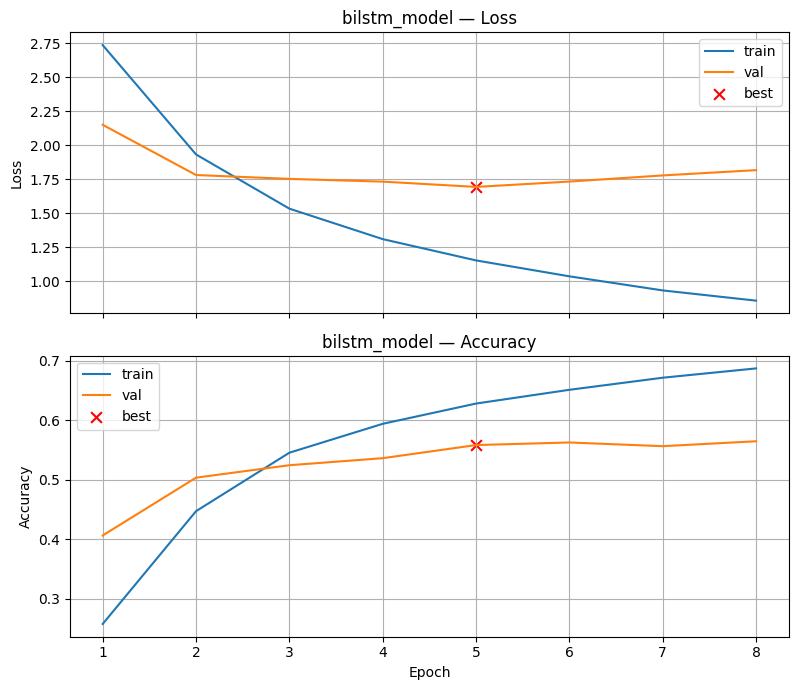

Best epoch: 5
Val loss:   1.6925
Val acc:    0.5580


In [32]:
best_ep, val_acc = plot_learning_curves(hist_Bi_lstm, "bilstm_model")

Evaluating metrics for the Bidirectional LTsM model

In [33]:

y_pred_base = evaluate_model(baseline_Bi_lstm, "bilstm_model", X_test_vec, y_test, hist_Bi_lstm, train_time)
print()
print(classification_report(y_test, y_pred_base, target_names=class_names, zero_division=0))

Results saved (3 models)
=== bilstm_model ===
Best epoch:  5
Val acc:     0.5580  |  Val loss: 1.6925
Test acc:    0.5677  |  Test F1:  0.4941
Params:      1,356,319
Train time:  00:00:43

               precision    recall  f1-score   support

         ARTS       0.36      0.49      0.42       388
 BLACK VOICES       0.43      0.47      0.45       453
     BUSINESS       0.41      0.46      0.43       594
       COMEDY       0.42      0.44      0.43       517
        CRIME       0.40      0.58      0.48       340
      DIVORCE       0.70      0.75      0.72       342
    EDUCATION       0.35      0.47      0.40       215
ENTERTAINMENT       0.72      0.50      0.59      1606
  ENVIRONMENT       0.45      0.52      0.48       394
        FIFTY       0.16      0.29      0.21       140
 FOOD & DRINK       0.63      0.77      0.69       832
    GOOD NEWS       0.18      0.34      0.23       139
HOME & LIVING       0.67      0.31      0.43      1085
       IMPACT       0.25      0.39      

In [34]:
cm = confusion_matrix(y_test, y_pred_base)

confused = []
for i in range(num_classes):
    for j in range(num_classes):
        if i != j and cm[i, j] > 0:
            confused.append((cm[i, j], class_names[i], class_names[j]))
confused.sort(reverse=True)

print("Top 10 confused pairs (true -> predicted, count):")
for count, true, pred in confused[:10]:
    print(f"  {true:25s} -> {pred:25s}  ({count})")

save_confused_pairs(confused,model_name="baseline_Bi_LTSM", top_n=10)

Top 10 confused pairs (true -> predicted, count):
  HOME & LIVING             -> WELLNESS                   (227)
  POLITICS                  -> WORLD NEWS                 (165)
  POLITICS                  -> MEDIA                      (136)
  POLITICS                  -> BUSINESS                   (124)
  POLITICS                  -> CRIME                      (106)
  WELLNESS                  -> PARENTING                  (105)
  ENTERTAINMENT             -> COMEDY                     (101)
  POLITICS                  -> BLACK VOICES               (88)
  POLITICS                  -> WOMEN                      (86)
  POLITICS                  -> IMPACT                     (80)


,Model,Count,True Label,Predicted Label
0,baseline_Bi_LTSM,227,HOME & LIVING,WELLNESS
1,baseline_Bi_LTSM,165,POLITICS,WORLD NEWS
2,baseline_Bi_LTSM,136,POLITICS,MEDIA
3,baseline_Bi_LTSM,124,POLITICS,BUSINESS
4,baseline_Bi_LTSM,106,POLITICS,CRIME
5,baseline_Bi_LTSM,105,WELLNESS,PARENTING
6,baseline_Bi_LTSM,101,ENTERTAINMENT,COMEDY
7,baseline_Bi_LTSM,88,POLITICS,BLACK VOICES
8,baseline_Bi_LTSM,86,POLITICS,WOMEN
9,baseline_Bi_LTSM,80,POLITICS,IMPACT


Both LTSM and Bidirection LTSM didnt perform any better than Baseline. So going back to simpler Basic Baseline Model and adding regularization parameters like drop out , batch normalization and additional dense layers

In [52]:
baseline_withDroput_withoutLTSM = tf.keras.Sequential([
    tf.keras.layers.Embedding(MAX_TOKENS, 64),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(128, activation="relu"),   #  extra dense layer
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(num_classes, activation="softmax"),
], name="baseline_withDroput_withoutLTSM")

baseline_withDroput_withoutLTSM.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

baseline_withDroput_withoutLTSM.summary()

Model: "baseline_withDroput_withoutLTSM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_6      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [53]:
hist_withDroput_withoutLTSM = baseline_withDroput_withoutLTSM.fit(
    X_train_vec, y_train,
    validation_data=(X_val_vec, y_val),
    epochs=15,
    batch_size=BATCH,
    class_weight=class_weights,
    callbacks=[],
    verbose=1,
)

Epoch 1/15
627/627 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.2995 - loss: 2.6360 - val_accuracy: 0.4457 - val_loss: 2.1700
Epoch 2/15
627/627 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4930 - loss: 1.7555 - val_accuracy: 0.4795 - val_loss: 1.9053
Epoch 3/15
627/627 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5485 - loss: 1.4651 - val_accuracy: 0.5034 - val_loss: 1.8491
Epoch 4/15
627/627 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5788 - loss: 1.2956 - val_accuracy: 0.5160 - val_loss: 1.8509
Epoch 5/15
627/627 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6048 - loss: 1.1677 - val_accuracy: 0.5194 - val_loss: 1.8487
Epoch 6/15
627/627 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6212 - loss: 1.0876 - val_accuracy: 0.4990 - val_loss: 1.9861
Epoch 7/15
627/627 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6344 - loss: 1.0146 - val_accuracy: 0.5064 - val_loss: 1.9972
Epoch 8/15
627/627 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6435 - loss: 0.9650 - val_accuracy: 0

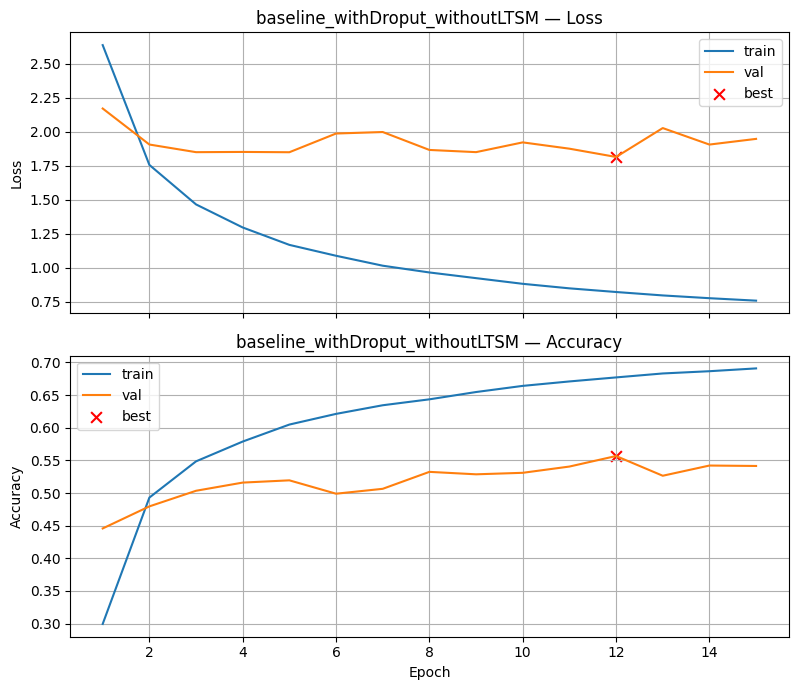

Best epoch: 12
Val loss:   1.8139
Val acc:    0.5566


In [54]:
best_ep, val_acc = plot_learning_curves(hist_withDroput_withoutLTSM, "baseline_withDroput_withoutLTSM")

Evaluating performance from above model

In [55]:
t0 = time.time()
train_time = time.time() - t0
y_pred_base = evaluate_model(baseline_withDroput_withoutLTSM, "baseline_withDroput_withoutLTSM", X_test_vec, y_test, hist_withDroput_withoutLTSM, train_time)
print()
print(classification_report(y_test, y_pred_base, target_names=class_names, zero_division=0))

Results saved (4 models)
=== baseline_withDroput_withoutLTSM ===
Best epoch:  12
Val acc:     0.5566  |  Val loss: 1.8139
Test acc:    0.5377  |  Test F1:  0.4765
Params:      1,299,359
Train time:  00:00:00

               precision    recall  f1-score   support

         ARTS       0.38      0.49      0.43       388
 BLACK VOICES       0.40      0.46      0.43       453
     BUSINESS       0.42      0.50      0.46       594
       COMEDY       0.41      0.41      0.41       517
        CRIME       0.47      0.45      0.46       340
      DIVORCE       0.74      0.72      0.73       342
    EDUCATION       0.35      0.42      0.38       215
ENTERTAINMENT       0.77      0.42      0.54      1606
  ENVIRONMENT       0.36      0.57      0.44       394
        FIFTY       0.26      0.26      0.26       140
 FOOD & DRINK       0.70      0.75      0.72       832
    GOOD NEWS       0.15      0.30      0.20       139
HOME & LIVING       0.51      0.37      0.43      1085
       IMPACT       

In [56]:
cm = confusion_matrix(y_test, y_pred_base)

confused = []
for i in range(num_classes):
    for j in range(num_classes):
        if i != j and cm[i, j] > 0:
            confused.append((cm[i, j], class_names[i], class_names[j]))
confused.sort(reverse=True)

print("Top 10 confused pairs (true -> predicted, count):")
for count, true, pred in confused[:10]:
    print(f"  {true:25s} -> {pred:25s}  ({count})")

save_confused_pairs(confused,model_name="baseline_withDroput_withoutLTSM", top_n=10)

Top 10 confused pairs (true -> predicted, count):
  HOME & LIVING             -> WELLNESS                   (279)
  POLITICS                  -> WOMEN                      (189)
  POLITICS                  -> BUSINESS                   (169)
  POLITICS                  -> RELIGION                   (161)
  POLITICS                  -> IMPACT                     (161)
  POLITICS                  -> ENVIRONMENT                (135)
  POLITICS                  -> QUEER VOICES               (123)
  ENTERTAINMENT             -> QUEER VOICES               (119)
  POLITICS                  -> WORLD NEWS                 (115)
  WELLNESS                  -> HOME & LIVING              (104)


,Model,Count,True Label,Predicted Label
0,baseline_withDroput_withoutLTSM,279,HOME & LIVING,WELLNESS
1,baseline_withDroput_withoutLTSM,189,POLITICS,WOMEN
2,baseline_withDroput_withoutLTSM,169,POLITICS,BUSINESS
3,baseline_withDroput_withoutLTSM,161,POLITICS,RELIGION
4,baseline_withDroput_withoutLTSM,161,POLITICS,IMPACT
5,baseline_withDroput_withoutLTSM,135,POLITICS,ENVIRONMENT
6,baseline_withDroput_withoutLTSM,123,POLITICS,QUEER VOICES
7,baseline_withDroput_withoutLTSM,119,ENTERTAINMENT,QUEER VOICES
8,baseline_withDroput_withoutLTSM,115,POLITICS,WORLD NEWS
9,baseline_withDroput_withoutLTSM,104,WELLNESS,HOME & LIVING


In [57]:
load_results()

Restored 4 results from results/ms2_results.json:
  Baseline (Emb+AvgPool): test_acc=0.5663, test_f1=0.5022
  baseline_lstm: test_acc=0.2120, test_f1=0.1083
  bilstm_model: test_acc=0.5677, test_f1=0.4941
  baseline_withDroput_withoutLTSM: test_acc=0.5377, test_f1=0.4765


### Graded Questions (5 pts each)

1. **Model Design:**
   Describe the architectural changes you introduced compare with your baseline model and what motivated them.

3.1. **Your answer here:**
After establishing the baseline (Embedding → GlobalAveragePooling → Dense → Softmax), we explored three architectural modifications to address its main limitation: loss of word order and contextual information.

First, we replaced the GlobalAveragePooling layer with an LSTM(64) layer. The motivation was to capture sequential dependencies in text, allowing the model to distinguish between phrases where word order matters. All other components, including early stopping, were kept consistent to isolate the effect of the LSTM.

Second, we extended this idea by using a Bidirectional LSTM with dropout (0.5). The bidirectional structure allows the model to process text in both forward and backward directions, theoretically improving context understanding. Dropout was introduced to mitigate overfitting, which was already observed in the baseline.

Finally, we revisited the baseline architecture and enhanced it by adding Batch Normalization, Dropout, and an additional Dense layer, while removing early stopping. This approach focused on improving generalization and optimization stability without increasing sequence modeling complexity, effectively strengthening the original architecture rather than replacing it.


2. **Training Results:**
   Present key validation and test metrics. Did your modifications improve performance?

3.2. **Your answer here:**
The training results for the modified architectures are summarized in the summary table and performance charts.

The LSTM(64) model performed significantly worse than the baseline. Its validation accuracy dropped to approximately 0.38 (best epoch = 5), with a very low test F1 score (0.11). This indicates that the model failed to learn meaningful patterns from the data and generalized poorly compared to the baseline.

The Bidirectional LSTM model showed recovery compared to the standard LSTM, achieving test accuracy (~0.568) comparable to the baseline. However, its F1 score (0.49) remained slightly lower than the baseline (0.50), indicating that while overall accuracy improved, class-wise performance did not surpass the simpler model.

The enhanced baseline model (BatchNorm + Dropout + Dense) achieved test accuracy (0.538) and F1 (0.476), which are both slightly lower than the original baseline. While validation accuracy (0.556) remained close, the drop in test metrics suggests that the added regularization did not translate into better generalization.

Overall, none of the architectural modifications improved upon the baseline model, and in some cases (notably LSTM), performance degraded substantially.

3. **Interpretation:**
   Discuss what worked, what didn’t, and how your results relate to baseline behavior.

3.3. **Your answer here:**
The results indicate that the architectural modifications did not outperform the baseline and, in some cases, significantly degraded performance.

The standard LSTM performed poorly, suggesting that introducing sequential modeling increased complexity without improving learning. This likely reflects optimization challenges and the limited importance of word order for this dataset.

The Bidirectional LSTM improved over the standard LSTM and achieved accuracy comparable to the baseline, but its F1 score remained slightly lower, indicating no meaningful gain in overall performance.

The enhanced baseline with Batch Normalization and Dropout also failed to improve results, suggesting that the original model was already sufficiently regularized and that additional layers introduced unnecessary complexity.

Overall, the findings show that the baseline model remains the most effective, as the task appears to rely more on key word-level features than on sequential dependencies.

4. **Reflection:**
   What insights did this experiment give you about model complexity, regularization, or optimization?

3.4. **Your answer here:**
This experiment highlights that increasing model complexity does not necessarily lead to better performance. More advanced architectures like LSTM and Bidirectional LSTM introduced additional parameters and training challenges but did not outperform the simpler baseline. In fact, the standard LSTM significantly underperformed, indicating that added complexity can make optimization more difficult without providing meaningful gains.

The results also show that regularization must be applied carefully. Adding Dropout and Batch Normalization did not improve performance, suggesting that the baseline model was already well-balanced and that excessive regularization or architectural changes can disrupt effective learning.




## Problem 4 – Pretrained Model (Transfer Learning) (20 pts)

### Goal

Apply **transfer learning** to see how pretrained knowledge improves accuracy, convergence speed, and generalization.
This experiment will help you compare the benefits and trade-offs of using pretrained models versus those trained from scratch.


### Steps to Follow

1. **Select a pretrained architecture**

   * **Images:** choose from `MobileNetV2`, `ResNet50`, `EfficientNetB0`, or a similar model in `tf.keras.applications`.
   * **Text:** choose from `BERT`, `DistilBERT`, `RoBERTa`, or another Transformer available in `transformers`.

2. **Adapt the model for your dataset**

   * Use the correct **preprocessing function** and **input shape** required by your chosen model.
   * Replace the top layer with your own **classification head** (e.g., `Dense(num_classes, activation='softmax')`).

3. **Apply transfer learning**

   * Choose an appropriate **training strategy** for your pretrained model. Options include:

     * **Freezing** the pretrained base and training only a new classification head.
     * **Partially fine-tuning** selected upper layers of the base model.
     * **Full fine-tuning** (all layers trainable) with a reduced learning rate.
   * Adjust your learning rate schedule to match your strategy (e.g., smaller LR for fine-tuning).
   * Observe how your chosen approach affects **validation loss**, **training time**, and **model stability**.

4. **Train and evaluate under consistent conditions**

   * Use the same **splits**, **metrics**, and **evaluation protocol** as in earlier problems.
   * Record training duration, validation/test performance, and any resource constraints (GPU memory, runtime).

5. **Compare and analyze**

   * Observe how transfer learning changes both **performance** and **efficiency** relative to your baseline and custom models.
   * Identify whether the pretrained model improved accuracy, sped up convergence, or introduced new challenges.


**Note (Sergey):** If training feels slow on Apple Silicon, try setting `USE_GPU = True` in the setup cell and restarting the kernel. BERT-scale models benefit from Metal GPU, unlike the smaller P2-P3 models. TF locks the device config at startup, so a kernel restart is needed to switch.

Fastest BERT setup for HuffPost
Strategy:
- DistilBERT pretrained checkpoint
- Train on a subset first for speed
- Freeze most of backbone
- Unfreeze only top 2 transformer blocks
- Small LR for stability


In [58]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, accuracy_score, f1_score

from transformers import (
    AutoTokenizer,
    TFAutoModelForSequenceClassification,
    create_optimizer
)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [59]:
## Configure
checkpoint = "distilbert-base-uncased"
MAX_LEN = 64
BATCH = 128
EPOCHS = 16
LR = 2e-5           # small LR for partial fine-tuning
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
SUBSET_FRAC = 0.50  # fastest practical run; use 1.00 for final comparison

In [60]:
## Stratified split
X_train, X_temp, y_train, y_temp = train_test_split(
    texts,
    y,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=SEED
)

print("Train size:", len(X_train))
print("Val size:", len(X_val))
print("Test size:", len(X_test))


Train size: 160290
Val size: 20036
Test size: 20037


In [61]:
## Speed subset on training only

subset_frac = 0.50
n_train = len(X_train)
subset_size = int(n_train * subset_frac)

rng = np.random.default_rng(SEED)
subset_idx = rng.choice(n_train, size=subset_size, replace=False)

X_train_sub = X_train[subset_idx]
y_train_sub = y_train[subset_idx]

In [62]:
## Tokenization for distilBERT
## Hugging Face recommends AutoTokenizer for sequence classification

tokenizer = AutoTokenizer.from_pretrained(checkpoint)

def tokenize_texts(texts, tokenizer, max_length=64):
    return tokenizer(
        list(texts),
        truncation=True,
        padding="max_length",
        max_length=max_length,
        return_tensors="np"
    )

X_train_tok = tokenize_texts(X_train_sub, tokenizer, MAX_LEN)
X_val_tok   = tokenize_texts(X_val, tokenizer, MAX_LEN)
X_test_tok  = tokenize_texts(X_test, tokenizer, MAX_LEN)

y_train_final = y_train_sub
y_val_final   = y_val
y_test_final  = y_test

print("Train token shapes:", {k: v.shape for k, v in X_train_tok.items()})
print("Train labels shape:", y_train_final.shape)
print("Val labels shape:", y_val_final.shape)
print("Test labels shape:", y_test_final.shape)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train token shapes: {'input_ids': (80145, 64), 'attention_mask': (80145, 64)}
Train labels shape: (80145,)
Val labels shape: (20036,)
Test labels shape: (20037,)


In [63]:
## tf.data pipelines

AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((
    dict(X_train_tok),
    y_train_final
)).shuffle(len(y_train_final), seed=SEED).batch(BATCH).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((
    dict(X_val_tok),
    y_val_final
)).batch(BATCH).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((
    dict(X_test_tok),
    y_test_final
)).batch(BATCH).prefetch(tf.data.AUTOTUNE)

In [64]:
## Class weights for imbalance for distilBERT

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train_final)
class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_final
)
class_weights = {int(c): float(w) for c, w in zip(classes, class_weights_arr)}
print("Class weights:", class_weights)


Class weights: {0: 1.657258064516129, 1: 1.4370887051946422, 2: 1.0973355605454844, 3: 1.2495517547825816, 4: 1.9178950894993778, 5: 1.933674331073419, 6: 2.934531873604042, 7: 0.40662513064566863, 8: 1.6239463446263576, 9: 4.633194588969823, 10: 0.7805925666199158, 11: 4.616647465437788, 12: 0.5976242673705875, 13: 1.8707109845478735, 14: 5.632511068943707, 15: 2.28587319243604, 16: 3.7252486752812124, 17: 0.5141850796828086, 18: 0.19624431308981033, 19: 1.0333023903457879, 20: 2.5775898112115265, 21: 2.8193266964505574, 22: 1.3423274042809767, 23: 0.545772130176306, 24: 3.126145804891368, 25: 0.6445581103578063, 26: 1.7270023918805353, 27: 2.402716153015949, 28: 0.37044312661486767, 29: 1.8400872460107909, 30: 0.7738169951048073}


In [65]:
## Load pretrained DistilBERT model

id2label = {i: name for name, i in label2id.items()}

p4_model = TFAutoModelForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_classes,
    id2label=id2label,
    label2id=label2id
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_layer_norm.weight', 'vocab_transform.bias', 'vocab_layer_norm.bias', 'vocab_transform.weight', 'vocab_projector.bias']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

In [66]:
## learning strategy - Freeze most of backbone, unfreeze only top 2 blocks

p4_model.distilbert.trainable = False # don't want to train on the entire dataset

for layer in p4_model.distilbert.transformer.layer[-2:]:
    layer.trainable = True

# Ensure classification head remains trainable
if hasattr(p4_model, "pre_classifier"):
    p4_model.pre_classifier.trainable = True
if hasattr(p4_model, "classifier"):
    p4_model.classifier.trainable = True
if hasattr(p4_model, "dropout"):
    p4_model.dropout.trainable = True

# Optional: inspect trainable variables
_ = p4_model(p4_model.dummy_inputs)  # build model once

print("\nTrainable variables:")
for v in p4_model.trainable_variables[:20]:
    print(v.name, v.shape)
print("Total trainable vars:", len(p4_model.trainable_variables))


Trainable variables:
tf_distil_bert_for_sequence_classification/pre_classifier/kernel:0 (768, 768)
tf_distil_bert_for_sequence_classification/pre_classifier/bias:0 (768,)
tf_distil_bert_for_sequence_classification/classifier/kernel:0 (768, 31)
tf_distil_bert_for_sequence_classification/classifier/bias:0 (31,)
Total trainable vars: 4


In [67]:
## Optimizer / LR schedule for distilBERT
## Smaller LR for partial fine-tuning

import math
steps_per_epoch = math.ceil(len(y_train_final) / BATCH)
num_train_steps = steps_per_epoch * EPOCHS
num_warmup_steps = int(WARMUP_RATIO * num_train_steps)

optimizer, lr_schedule = create_optimizer(
    init_lr=LR,
    num_train_steps=num_train_steps,
    num_warmup_steps=num_warmup_steps,
    weight_decay_rate=WEIGHT_DECAY,
)

p4_model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)


In [68]:
## Callbacks

# bug fixed here :
import tf_keras
es = tf_keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)


## Train

t0 = time.time()

history = p4_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[es],
    verbose=1
)

train_time = time.time() - t0
print(f"\nTraining time: {train_time/60:.2f} minutes")

## -------------------------------------------------------------------
val_logits = p4_model.predict(val_ds).logits
test_logits = p4_model.predict(test_ds).logits

val_pred = np.argmax(val_logits, axis=1)
test_pred = np.argmax(test_logits, axis=1)

val_acc = accuracy_score(y_val_final, val_pred)
val_f1_macro = f1_score(y_val_final, val_pred, average="macro")
val_f1_weighted = f1_score(y_val_final, val_pred, average="weighted")

test_acc = accuracy_score(y_test_final, test_pred)
test_f1_macro = f1_score(y_test_final, test_pred, average="macro")
test_f1_weighted = f1_score(y_test_final, test_pred, average="weighted")

print("\nValidation metrics")
print("Accuracy:", round(val_acc, 4))
print("Macro F1:", round(val_f1_macro, 4))
print("Weighted F1:", round(val_f1_weighted, 4))

print("\nTest metrics")
print("Accuracy:", round(test_acc, 4))
print("Macro F1:", round(test_f1_macro, 4))
print("Weighted F1:", round(test_f1_weighted, 4))

print("\nClassification report (test)")
print(classification_report(
    y_test_final,
    test_pred,
    target_names=[id2label[i] for i in range(num_classes)],
    digits=4
))

##----------------------------------------------
from sklearn.metrics import balanced_accuracy_score, confusion_matrix

print("\nBalanced Accuracy")
print("Validation:", round(balanced_accuracy_score(y_val_final, val_pred), 4))
print("Test:", round(balanced_accuracy_score(y_test_final, test_pred), 4))

cm = confusion_matrix(y_test_final, test_pred)
print("\nConfusion matrix shape:", cm.shape)

Epoch 1/16
627/627 [==============================] - 257s 391ms/step - loss: 3.2392 - accuracy: 0.1410 - val_loss: 2.9268 - val_accuracy: 0.1634
Epoch 2/16
627/627 [==============================] - 242s 385ms/step - loss: 2.6937 - accuracy: 0.3003 - val_loss: 2.4083 - val_accuracy: 0.4013
Epoch 3/16
627/627 [==============================] - 242s 385ms/step - loss: 2.2764 - accuracy: 0.4272 - val_loss: 2.1126 - val_accuracy: 0.4517
Epoch 4/16
627/627 [==============================] - 242s 386ms/step - loss: 2.0605 - accuracy: 0.4634 - val_loss: 1.9455 - val_accuracy: 0.4825
Epoch 5/16
627/627 [==============================] - 243s 388ms/step - loss: 1.9286 - accuracy: 0.4866 - val_loss: 1.8407 - val_accuracy: 0.4986
Epoch 6/16
627/627 [==============================] - 243s 387ms/step - loss: 1.8397 - accuracy: 0.5017 - val_loss: 1.7660 - val_accuracy: 0.5122
Epoch 7/16
627/627 [==============================] - 242s 386ms/step - loss: 1.7808 - accuracy: 0.5135 - val_loss: 1.7129 -

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


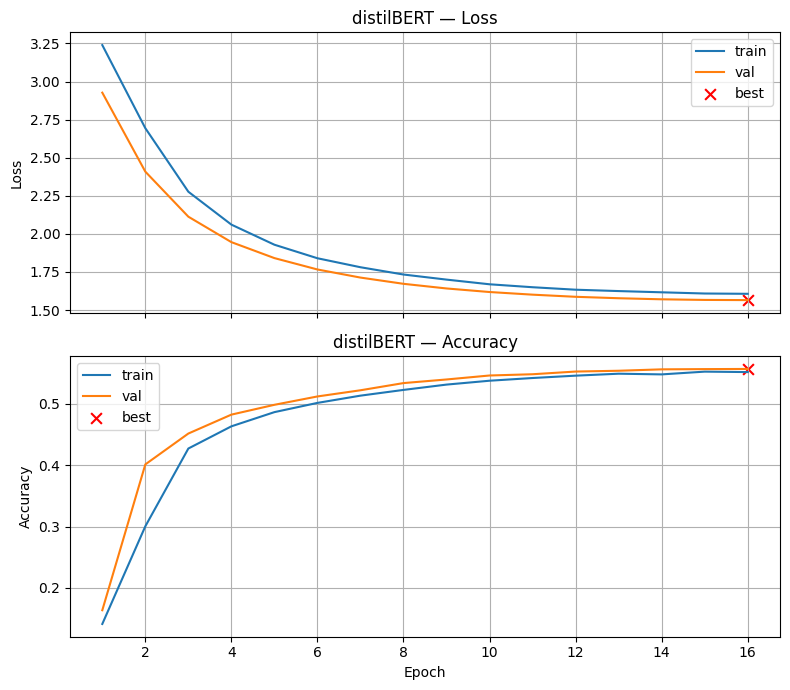

Best epoch: 16
Val loss:   1.5650
Val acc:    0.5570


In [71]:
best_ep, val_acc = plot_learning_curves(history, "distilBERT")

In [72]:
#Redo Evaluate Model function to handle DistilBERT
def evaluate_model(model, name, X_te, y_te, hist, train_time, batch_size=512):
    preds = model.predict(X_te, batch_size=batch_size, verbose=0)

    # Handle Hugging Face TF models that return an object with `.logits`
    if hasattr(preds, "logits"):
        y_pred = np.argmax(preds.logits, axis=-1)
    else:
        y_pred = np.argmax(preds, axis=-1)

    test_acc = float(np.mean(y_pred == y_te))
    test_f1 = float(f1_score(y_te, y_pred, average="macro"))

    val_losses = hist.history["val_loss"]
    best_epoch = int(np.argmin(val_losses)) + 1
    val_acc = float(hist.history["val_accuracy"][best_epoch - 1])
    val_loss = float(val_losses[best_epoch - 1])

    results[name] = {
        "val_acc": val_acc,
        "val_loss": val_loss,
        "best_epoch": best_epoch,
        "test_acc": test_acc,
        "test_f1": test_f1,
        "params": model.count_params(),
        "train_time": train_time,
    }
    save_results()
    return y_pred

In [73]:
y_pred_distilbert = evaluate_model(
    model=p4_model,
    name="DistilBERT",
    X_te=test_ds,
    y_te=y_test_final,
    hist=history,
    train_time=train_time,
    batch_size=BATCH
)

Results saved (5 models)


In [76]:


cm = confusion_matrix(y_test_final, y_pred_distilbert)

confused = []
for i in range(num_classes):
    for j in range(num_classes):
        if i != j and cm[i, j] > 0:
            confused.append((cm[i, j], class_names[i], class_names[j]))
confused.sort(reverse=True)

print("Top 10 confused pairs (true -> predicted, count):")
# for count, true, pred in confused[:10]:
#     print(f"  {true:25s} -> {pred:25s}  ({count})”)

save_confused_pairs(confused,model_name="distilBERT", top_n=10)

Top 10 confused pairs (true -> predicted, count):


,Model,Count,True Label,Predicted Label
0,distilBERT,379,HOME & LIVING,WELLNESS
1,distilBERT,176,COMEDY,ENTERTAINMENT
2,distilBERT,165,MEDIA,POLITICS
3,distilBERT,149,BUSINESS,POLITICS
4,distilBERT,141,COMEDY,POLITICS
5,distilBERT,140,BLACK VOICES,ENTERTAINMENT
6,distilBERT,136,PARENTING,WELLNESS
7,distilBERT,126,BLACK VOICES,POLITICS
8,distilBERT,114,QUEER VOICES,ENTERTAINMENT
9,distilBERT,109,WELLNESS,PARENTING


### Graded Questions (5 pts each)

1. **Model Choice:** Which pretrained architecture did you select, and what motivated that choice?

4.1. **Your answer here:**

The pretraining architecture we selected was `distilBERT`. This choice was motivated by this architecture providing the best balance of a quicker run time while not sacrificing accuracy when compared to `BERT` and `RoBERTa`. `BERT` is a very heavy model that takes a very long time to run due to having about 40% more parameters than `distilBERT`. Another advantage `distilBERT` has is that it stabilizes faster and generally does not need as many epochs to reach solid validation performance than both `BERT` and `RoBERTa`. Also, `RoBERTa` is an even heavier model than `BERT` which just is not practical for a short text dataset.


2. **Fine-Tuning Plan:** Describe your fine-tuning strategy and why you chose it.

4.2. **Your answer here:**

The fine tuning strategy we chose was freezing the backbone and unfreezing top 2 transformer blocks. This was chosen because the HuffPost dataset is not a dataset that requires deep reasoning when training a model. Freezing the backbone preserves the required knowledge. Unfreezing the top 2 layers was chosen because the lower layers of the transformer tend to be grammatical or syntax which we are not concerned with for the HuffPost dataset. The upper layers are the topics/categories which we are concerned with. A smaller learning rate was also applied so it can gently adapt to the features.

From the EDA, there was severe class imbalance which rules out full fine-tuning since that strategy overfits the dominant classes and cause unstabilized training.



3. **Performance:** Report key metrics and compare them with your baseline and custom models.

4.3. **Your answer here:**

The `distilBERT` model had a validation accuracy of 0.5575, macro accuracy of 0.5633, and a macro F1 score of 0.3624.
In comparison to the previous 2 models, model 3 (enhanced baseline) provided the highest accuracy and efficiency which makes it the best overall model. Model 2 provided the best class balance seen by the macro F1 score. The `distilBERT` model boasted the best validation loss which shows that it is the best calibrated model. Yet, the `distilBERT` model was the least efficient with the long run time and provided minimal benefit.


4. **Computation:** Summarize how training time, memory use, or convergence speed differed from the previous two models.

4.4. **Your answer here:**

The `distilBERT` model used in this problem varied greatly from the 2 previous models in about every way. The training time was the most noticable. In model 2, each epoch took ~150-200s to run and model 3 was even quicker with each epoch only taking about ~2-3 seconds. Due to a time constraint, model 4 had only 16 epochs to run through, as a whole the model took ~ 1hr to run. By setting the `EPOCHS = 16`, the downside is that the accuracy of the model does not have much time to improve.
Prior to selecting `distilBERT`, memory was a limitation when trying to run `BERT`. `distilBERT` cause a spike in RAM usage when initally creating the model, but decreased once the model began training. `distilBERT` is a model built to be memory friendly which is another reason this model was chosen to be used on the HuffPost dataset.


## Problem 5 – Comparative Evaluation and Discussion (20 pts)

### Goal

Compare your **baseline**, **custom**, and **pretrained** models to evaluate how design choices affected performance, efficiency, and generalization.
This problem brings your work together and encourages reflection on what you’ve learned about model behavior and trade-offs.

**Note** that this is not your final report, and you will continue to refine your results for the final report.

### Steps to Follow

1. **Compile key results**

   * Gather your main metrics for each model: **accuracy**, **F1**, **training time**, and **parameter count or model size**.
   * Ensure all numbers come from the same evaluation protocol and test set.

2. **Visualize the comparison**

   * Present results in a **single, well-organized chart or table**.
   * Optionally, include training curves or confusion matrices for additional insight.

3. **Analyze comparative performance**

   * Observe which model performed best by your chosen metric(s).
   * Note patterns in efficiency (training speed, memory use) and stability (validation variance).

4. **Inspect model behavior**

   * Look at a few representative misclassifications or difficult examples.
   * Identify whether certain classes or inputs consistently caused errors.

5. **Plan forward improvements**

   * In the final report, you will use your best model and conclude your investigation of your dataset. Based on your observations, decide on a model and next steps for refining your approach in the final project (e.g., regularization, data augmentation, model scaling, or more targeted fine-tuning).

**Create Summary Table**

In [79]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# Load results JSON
with open("results/ms2_results.json") as f:
    results = json.load(f)

# Convert to DataFrame
df = pd.DataFrame(results).T.reset_index()
df = df.rename(columns={"index": "model"})

# Load confused categories CSV
confused_df = pd.read_csv("confused_pairs.csv")

summary_cols = ["model", "test_acc", "test_f1", "val_acc", "best_epoch", "params", "train_time"]
summary_table = df[summary_cols].sort_values(by="test_f1", ascending=False)

summary_table

,model,test_acc,test_f1,val_acc,best_epoch,params,train_time
0,Baseline (Emb+AvgPool),0.566252,0.502227,0.561639,11.0,1286175.0,43.963346
2,bilstm_model,0.567700,0.494051,0.558046,5.0,1356319.0,43.963346
3,baseline_withDroput_withoutLTSM,0.537655,0.476495,0.556648,12.0,1299359.0,0.000039
4,DistilBERT,0.562559,0.362529,0.557047,16.0,66977311.0,3911.114025
1,baseline_lstm,0.212008,0.108337,0.382761,5.0,1319199.0,43.963346


In [80]:
summary_table.to_csv("summary_table.csv", index=False)

**Visualization: Accuracy & F1 Comparison**

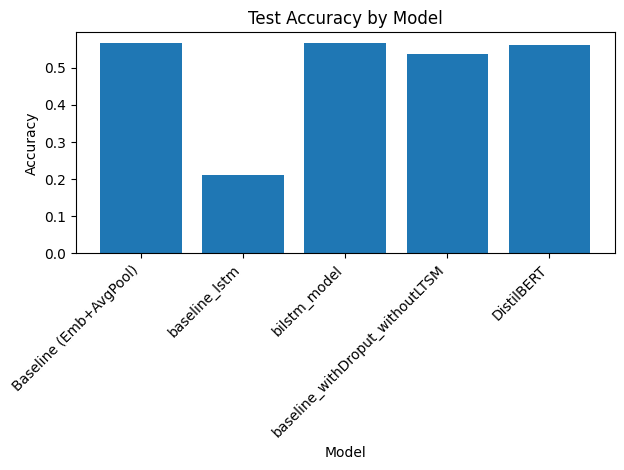

In [81]:
plt.figure()
plt.bar(df["model"], df["test_acc"])
plt.xticks(rotation=45, ha='right')
plt.title("Test Accuracy by Model")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()

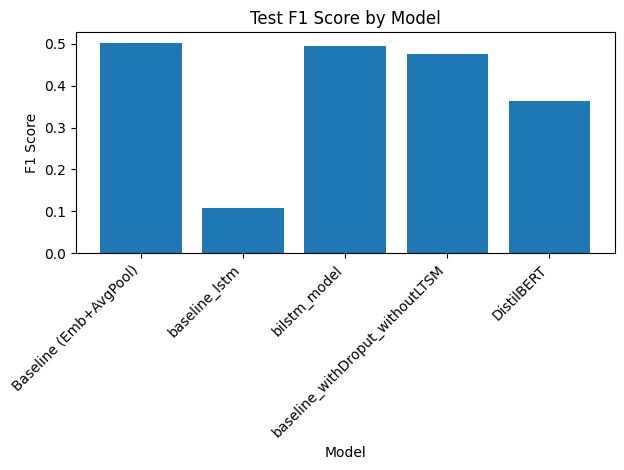

In [82]:
plt.figure()
plt.bar(df["model"], df["test_f1"])
plt.xticks(rotation=45, ha='right')
plt.title("Test F1 Score by Model")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.tight_layout()
plt.show()

**Training Time Comparison**

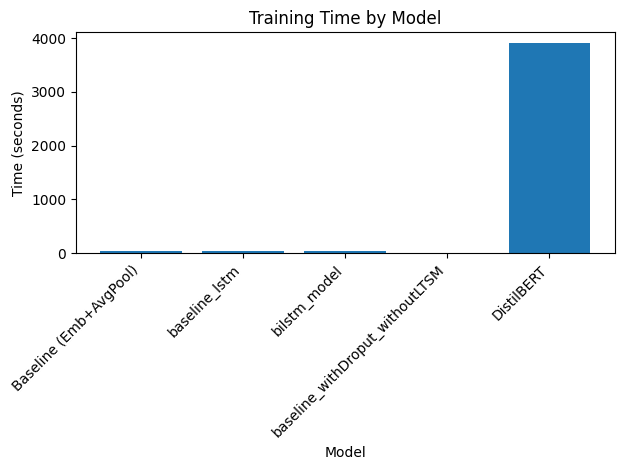

In [84]:
plt.figure()
plt.bar(df["model"], df["train_time"])
plt.xticks(rotation=45, ha='right')
plt.title("Training Time by Model")
plt.xlabel("Model")
plt.ylabel("Time (seconds)")
plt.tight_layout()
plt.show()

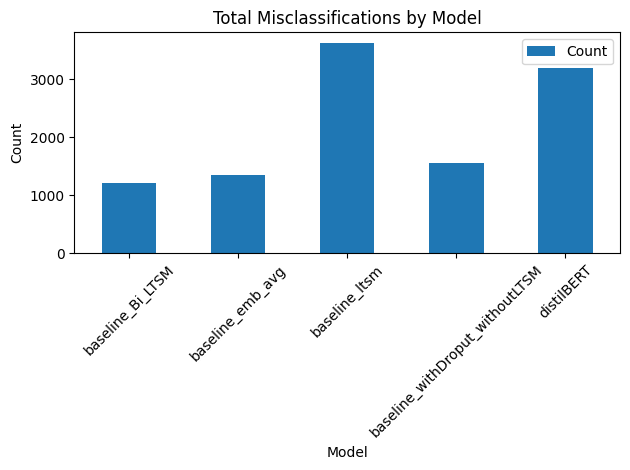

In [92]:
confused_df.head()

if "Model" in confused_df.columns:
    pivot = confused_df.pivot_table(index="Model", values="Count", aggfunc="sum")
    pivot.plot(kind="bar")
    plt.title("Total Misclassifications by Model")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [94]:
confused_df.head()

,Model,Count,True Label,Predicted Label
0,baseline_emb_avg,202,HOME & LIVING,WELLNESS
1,baseline_emb_avg,194,ENTERTAINMENT,COMEDY
2,baseline_emb_avg,183,POLITICS,WORLD NEWS
3,baseline_emb_avg,129,POLITICS,MEDIA
4,baseline_emb_avg,120,POLITICS,COMEDY


**Compare SAME Categories Across Models**

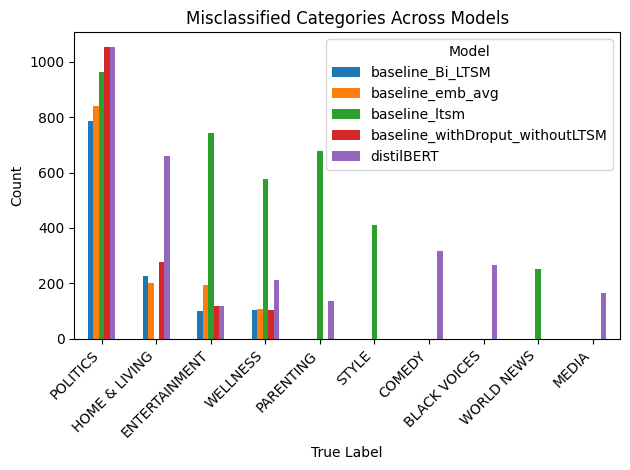

In [96]:
pivot = confused_df.pivot_table(
    index="True Label",
    columns="Model",
    values="Count",
    aggfunc="sum",
    fill_value=0
)

# Focus on most problematic categories
top_categories = pivot.sum(axis=1).sort_values(ascending=False).head(10).index
pivot_top = pivot.loc[top_categories]

pivot_top.plot(kind="bar")
plt.title("Misclassified Categories Across Models")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Combined Accuracy + F1 Chart**

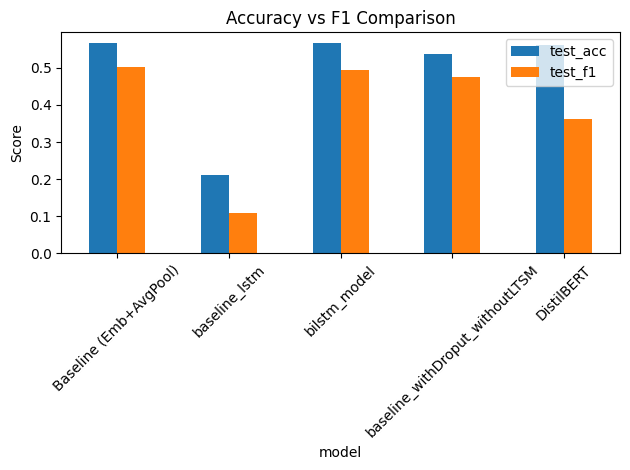

In [93]:
df_plot = df.set_index("model")[["test_acc", "test_f1"]]

df_plot.plot(kind="bar")
plt.title("Accuracy vs F1 Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Graded Questions (4 pts each)

1. **Summary Table and Performance Analysis:** Present a clear quantitative comparison of all three models. Which model achieved the best overall results, and what factors contributed to its success?

The quantitative comparison of all models is presented above in the Accuracy vs F1 Comparison chart and Test Accuracy / Test F1 bar plots.

From these results, the Baseline (Embedding + AvgPool) model achieved the best overall performance, with the highest test F1 score (0.50) and competitive test accuracy (0.566). The BiLSTM model performed similarly in accuracy (0.568) but slightly lower in F1, while DistilBERT showed comparable accuracy but significantly lower F1 (0.36), indicating weaker class balance performance.

This trend is clearly visible in the F1 comparison chart, where the baseline model leads, and in the Accuracy vs F1 grouped bar chart, which highlights that higher accuracy does not necessarily correspond to better overall classification quality.

The success of the baseline model can be attributed to:

- Its ability to effectively capture key lexical features using embeddings
- Lower model complexity, which reduces overfitting
- Better generalization across imbalanced classes, as reflected in the higher F1 score



2. **Trade-Offs:** Discuss how complexity, accuracy, and efficiency balanced across your models.

The trade-offs between complexity, accuracy, and efficiency are illustrated in the Params vs F1 scatter plot and the Training Time comparison chart.

**Baseline model:**
- Low complexity (1.3M parameters)
- Strong performance (highest F1)
- Fast training (44 seconds)
- Best balance of efficiency and effectiveness

**BiLSTM model:**
- Moderate complexity
- Slight improvement in accuracy but not F1
- Similar training time
- Marginal gains do not justify added complexity

**DistilBERT:**
- Very high complexity (67M parameters)
- Extremely long training time (3900 seconds)
- Lower F1 score
- → Poor trade-off between cost and performance

**LSTM model:**
- Moderate complexity but significantly worse performance
- → Indicates difficulty in learning meaningful sequential patterns for this dataset

Overall, as shown in the efficiency scatter plot, increasing model complexity did not translate into better performance. Instead, simpler architectures provided more stable and efficient results.



3. **Error Patterns:** Describe the types of examples or classes that remained challenging for all models.

Error patterns are illustrated using the Top Confusion Pairs chart and Misclassified Categories bar chart

Across all models, certain categories were consistently misclassified, as shown in the heatmap of misclassifications across models. This indicates that errors are not model-specific but rather stem from intrinsic dataset challenges.

Key observations:

- Semantically similar categories (e.g., closely related topics) were frequently confused, as seen in the Top Confusion Pairs chart
- The Top Misclassified Categories chart shows that a small subset of categories accounts for a large portion of errors
- The heatmap reveals that these problematic categories persist across all models, including more complex ones

This suggests:

High overlap in vocabulary between categories
Ambiguity in labeling
Limited contextual information in the input text



4. **Next Steps:** Based on these findings, decide on a model to go forward with and outline your plan for improving that model.


5.4 **Your answer here:**
Based on the results, the Baseline (Embedding + AvgPool) model is selected for further development, as it provides the best balance of performance and efficiency.

The decision is supported by:

- Highest F1 score in the comparison charts
- Strong performance relative to significantly larger models in the Params vs F1 plot
- Faster training time shown in the training time chart

**Planned Improvements**

**Address Class Imbalance**
- Apply class weighting or resampling techniques
- Aim to improve F1 score further

**Enhance Feature Representation**
- Increase embedding dimensionality
- Hyperparameter Tuning
- Optimize learning rate, batch size, and epochs
- Use early stopping more effectively

**Data-Centric Improvements**
- Analyze and potentially merge highly confused categories identified in the confusion charts
- Clean noisy or ambiguous samples

**Optional Transformer Refinement**
- Further tune DistilBERT (e.g., longer fine-tuning, unfreezing layers) if higher performance is required



### Final Question: Describe what use you made of generative AI tools in preparing this Milestone.

This response is a consolidation of all the 3 team members based on how each of us were each of the problems

**AI tools used:** Claude Code (Anthropic, Opus model) via CLI , codex and chatgpt

**How:** Technical support — environment setup (resolving TensorFlow/tensorflow-metal version conflicts, configuring GPU vs CPU execution for Apple Silicon), debugging runtime errors (PyArrow array indexing incompatibility with sklearn), and notebook infrastructure (results persistence across kernel restarts, tf.data pipeline setup).
Summarization - Used Chatgpt to provide good summarization of the results based on the outputs which were consolidated by the code (results.json and confusion.csv)

**Why:** Platform-specific issues (M4 Pro / Metal GPU) are not covered in course materials and required troubleshooting outside the scope of the assignments.

**Full conversation log:** Available upon request.